In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

In [36]:
X, y = make_classification(n_samples = 100, n_features = 2, n_informative = 1, n_redundant = 0,
                          n_classes = 2, n_clusters_per_class = 1, random_state = 41,
                          hypercube = False, class_sep = 30)

In [37]:
X.shape

(100, 2)

In [38]:
X

array([[ 0.82321545, -0.11697552],
       [ 0.37514771, -0.73115232],
       [ 0.26947761, -0.7081059 ],
       [-4.98744874, -2.01199214],
       [ 0.4231285 ,  1.63493163],
       [-4.2289949 ,  0.15599044],
       [-5.18865382,  1.07782053],
       [ 0.7096287 ,  0.80626713],
       [ 0.06531501,  0.74859527],
       [-5.3563263 ,  0.75152794],
       [-5.17487315, -0.90114581],
       [-5.17644221, -0.1815243 ],
       [ 0.60202649, -2.98092432],
       [ 1.42960231,  1.20500136],
       [-5.22359581,  0.78302407],
       [ 1.01127528,  0.42968688],
       [ 0.48288133, -0.73229726],
       [-5.27614308, -0.83930476],
       [ 0.44163889,  0.83727062],
       [-5.167179  , -0.10255323],
       [-5.67316396,  0.65867001],
       [-5.4617787 ,  0.92649819],
       [-4.71348919,  0.10216193],
       [ 2.2344006 ,  0.46886454],
       [-4.61308761,  0.45432938],
       [ 1.2379403 ,  1.8613386 ],
       [-5.18419324, -0.79255991],
       [-4.43807529, -1.0004391 ],
       [-5.79725951,

In [39]:
X.shape

(100, 2)

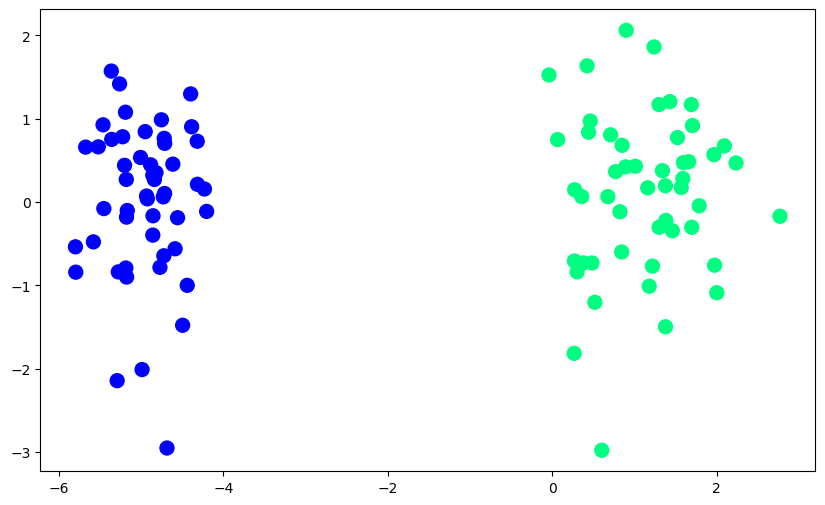

In [40]:
plt.figure(figsize = (10,6))
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'winter', s = 100)

In [41]:
np.insert(X, 0, 1, axis = 1)

array([[ 1.        ,  0.82321545, -0.11697552],
       [ 1.        ,  0.37514771, -0.73115232],
       [ 1.        ,  0.26947761, -0.7081059 ],
       [ 1.        , -4.98744874, -2.01199214],
       [ 1.        ,  0.4231285 ,  1.63493163],
       [ 1.        , -4.2289949 ,  0.15599044],
       [ 1.        , -5.18865382,  1.07782053],
       [ 1.        ,  0.7096287 ,  0.80626713],
       [ 1.        ,  0.06531501,  0.74859527],
       [ 1.        , -5.3563263 ,  0.75152794],
       [ 1.        , -5.17487315, -0.90114581],
       [ 1.        , -5.17644221, -0.1815243 ],
       [ 1.        ,  0.60202649, -2.98092432],
       [ 1.        ,  1.42960231,  1.20500136],
       [ 1.        , -5.22359581,  0.78302407],
       [ 1.        ,  1.01127528,  0.42968688],
       [ 1.        ,  0.48288133, -0.73229726],
       [ 1.        , -5.27614308, -0.83930476],
       [ 1.        ,  0.44163889,  0.83727062],
       [ 1.        , -5.167179  , -0.10255323],
       [ 1.        , -5.67316396,  0.658

In [42]:
np.ones(X.shape[1])

array([1., 1.])

In [43]:
def perceptron(X, y):
    X = np.insert(X, 0, 1, axis = 1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0, 100)
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights[0], weights[1:]

In [44]:
def step(z):
    return 1 if z > 0 else 0

In [45]:
intercept_, coef_ = perceptron(X, y)

In [46]:
print(coef_)
print(intercept_)

[1.1204053  0.40381514]
1.2000000000000002


In [47]:
m = -(coef_[0] / coef_[1])
c = -(intercept_ / coef_[1])

In [48]:
X_input = np.linspace(-3, 3, 100)
y_input = m * X_input + c

(-3.0, 2.0)

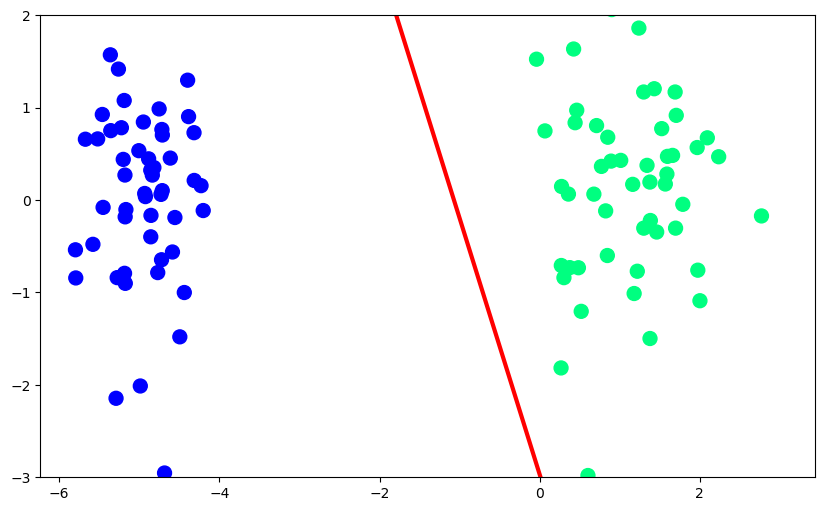

In [49]:
plt.figure(figsize = (10,6))
plt.plot(X_input, y_input, color = 'red', linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'winter', s = 100)
plt.ylim(-3, 2)

## Using sklearn

In [50]:
lor = LogisticRegression()
lor.fit(X, y)

LogisticRegression()

In [51]:
print(lor.coef_)
print(lor.intercept_)

[[1.77255101 0.01190507]]
[3.54700273]


In [52]:
m = -(lor.coef_[0][0] / lor.coef_[0][1])
c = -(intercept_ / lor.coef_[0][1])

In [53]:
X_input1 = np.linspace(-3, 3, 100)
y_input1 = m * X_input + c

(-3.0, 2.0)

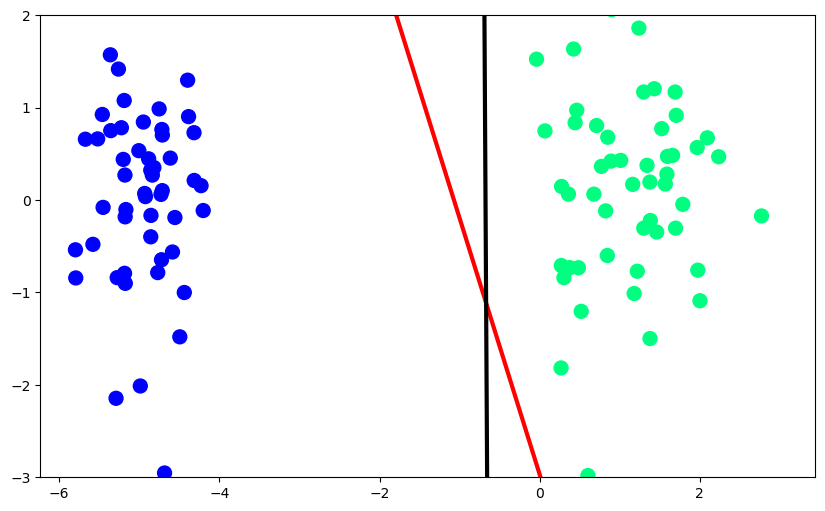

In [54]:
plt.figure(figsize=(10,6))
plt.plot(X_input, y_input, color = 'red', linewidth = 3)
plt.plot(X_input1, y_input1, color = 'black', linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'winter', s = 100)
plt.ylim(-3, 2)

## Sigmoid

In [55]:
def perceptron(X, y):
    X = np.insert(X, 0, 1, axis = 1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights[0], weights[1:]

In [56]:
def sigmoid(z):
    return 1 / (1 - np.exp(-z))

In [57]:
intercept_, coef_ = perceptron(X, y)

m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [58]:
X_input2 = np.linspace(-3, 3, 100)
y_input2 = m * X_input2 + b

(-3.0, 2.0)

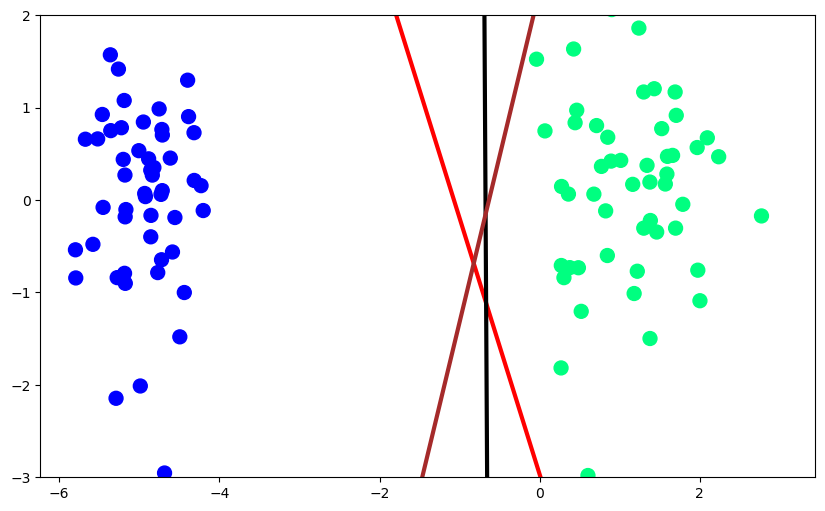

In [59]:
plt.figure(figsize=(10,6))
plt.plot(X_input, y_input, color = 'red', linewidth = 3)
plt.plot(X_input1, y_input1, color = 'black', linewidth = 3)
plt.plot(X_input2, y_input2, color = 'brown', linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'winter', s = 100)
plt.ylim(-3, 2)